In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

import amigo
from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [3]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/easy_binary/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [4]:
ois = [
    amigo.vis_analysis.AmigoOIData(oi_data) for filt, oi_data in cal_vis_outputs.items()
]
oi = ois[-1]

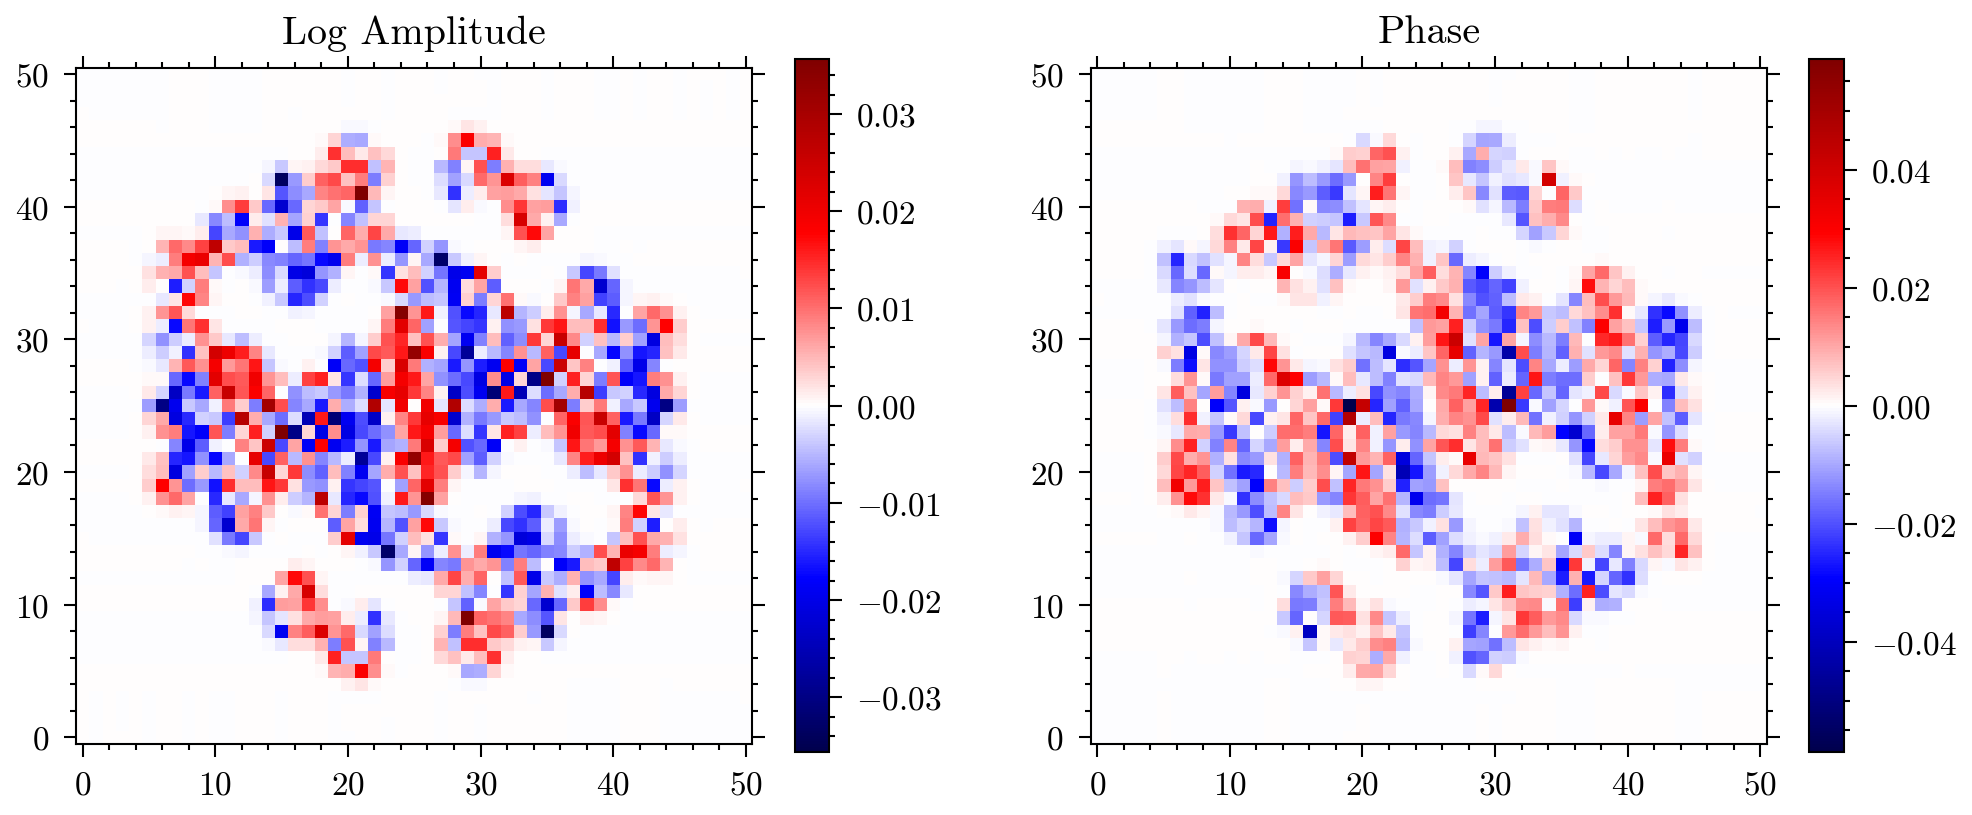

In [5]:
from amigo.vis_models import vis_to_im

# Get the discos
data, err = oi.flatten_data()
orig_log_amp, orig_phase = np.array_split(data, 2)

# Project to pixels
log_amp = np.dot(np.linalg.pinv(oi.vis_mat), orig_log_amp)
phase = np.dot(np.linalg.pinv(oi.phi_mat), orig_phase)

uv_npix = 51
log_amp, phase = vis_to_im(log_amp, phase, (uv_npix, uv_npix))

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Log Amplitude")
plt.imshow(log_amp, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(phase, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

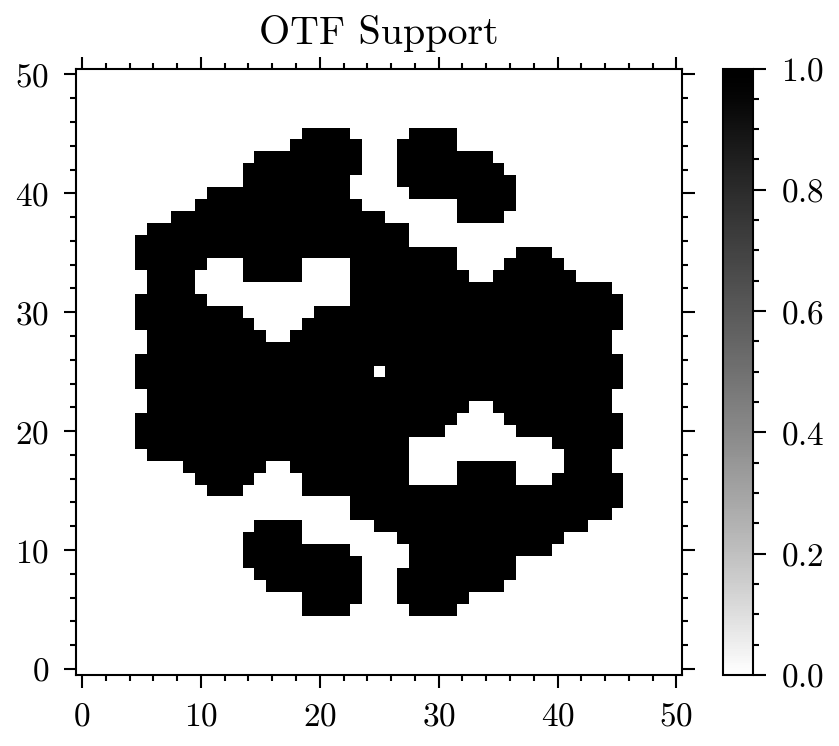

In [6]:
from jax import vmap

# Project to pixels
rand_vals = jr.normal(jr.key(0), (1000, *orig_log_amp.shape))
rand_amp = vmap(lambda x: np.dot(np.linalg.pinv(oi.vis_mat), x))(rand_vals)
rand_phase = vmap(lambda x: np.dot(np.linalg.pinv(oi.phi_mat), x))(rand_vals)
rand_amp, rand_phase = vmap(lambda a, p: vis_to_im(a, p, (51, 51)))(
    rand_amp, rand_phase
)

otf_support = rand_amp.var(0) > 0.01


plt.imshow(otf_support, cmap="gray_ur", vmin=0, vmax=1)
plt.colorbar()
plt.title("OTF Support")
plt.show()

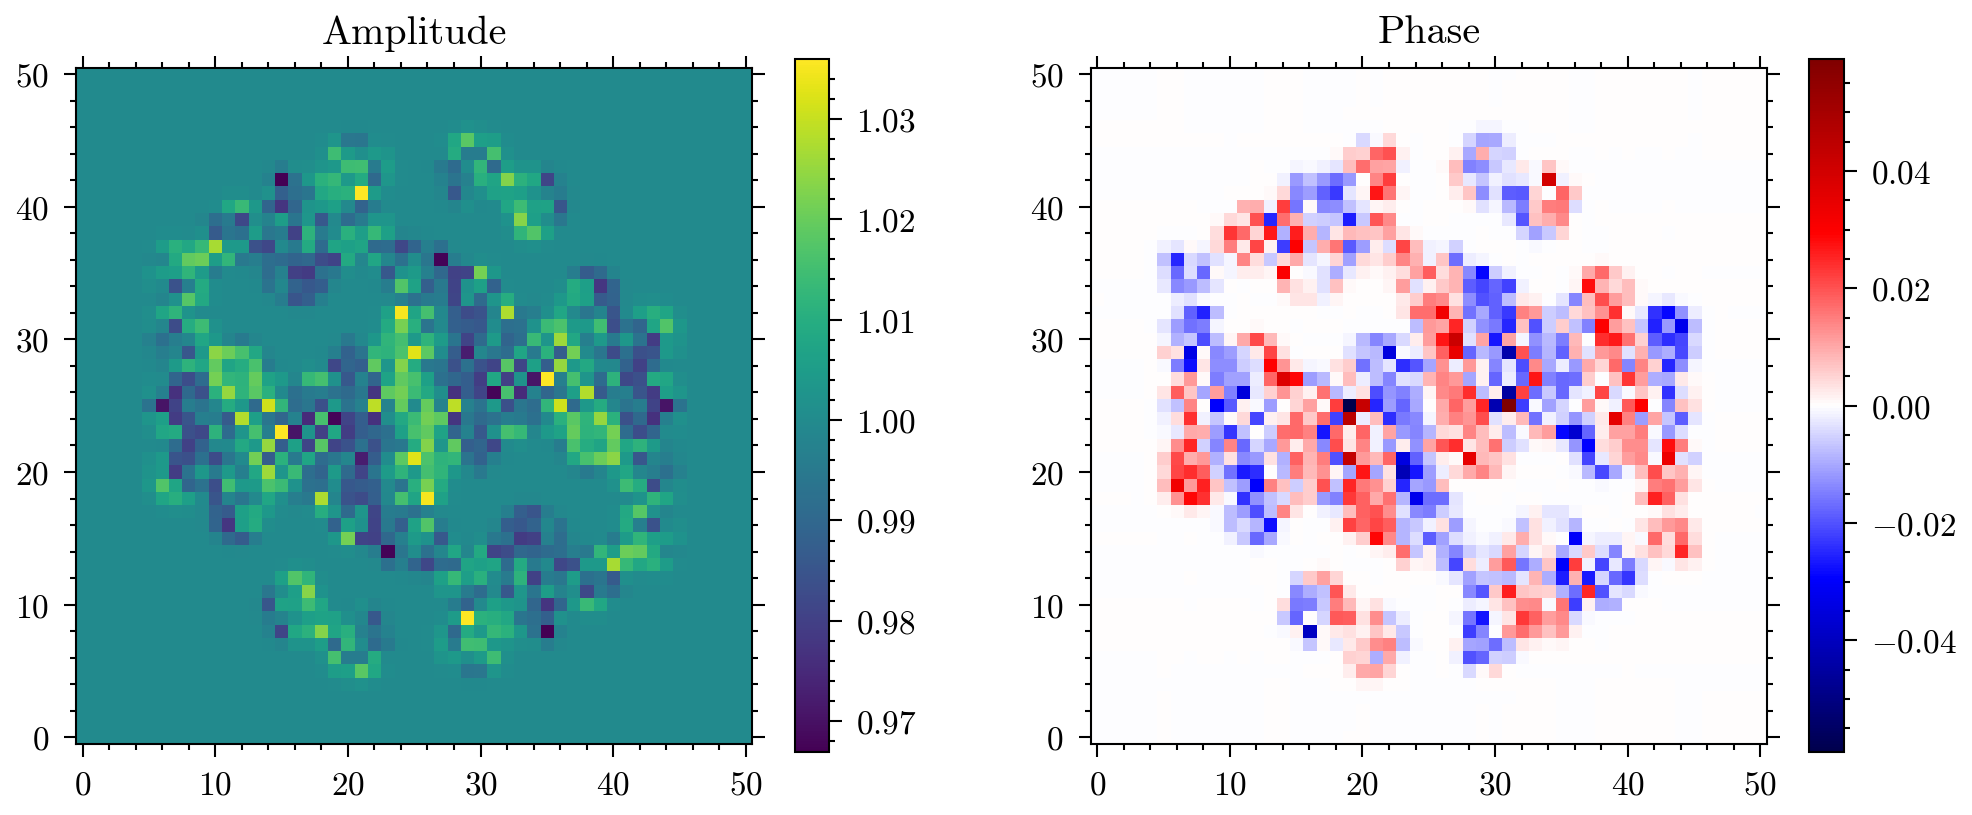

In [7]:
pix_cvis = np.exp(log_amp + 1j * phase)

# masking
masked_pix_cvis = np.where(otf_support, pix_cvis, 0 + 0j)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(pix_cvis.real, cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(pix_cvis.imag, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

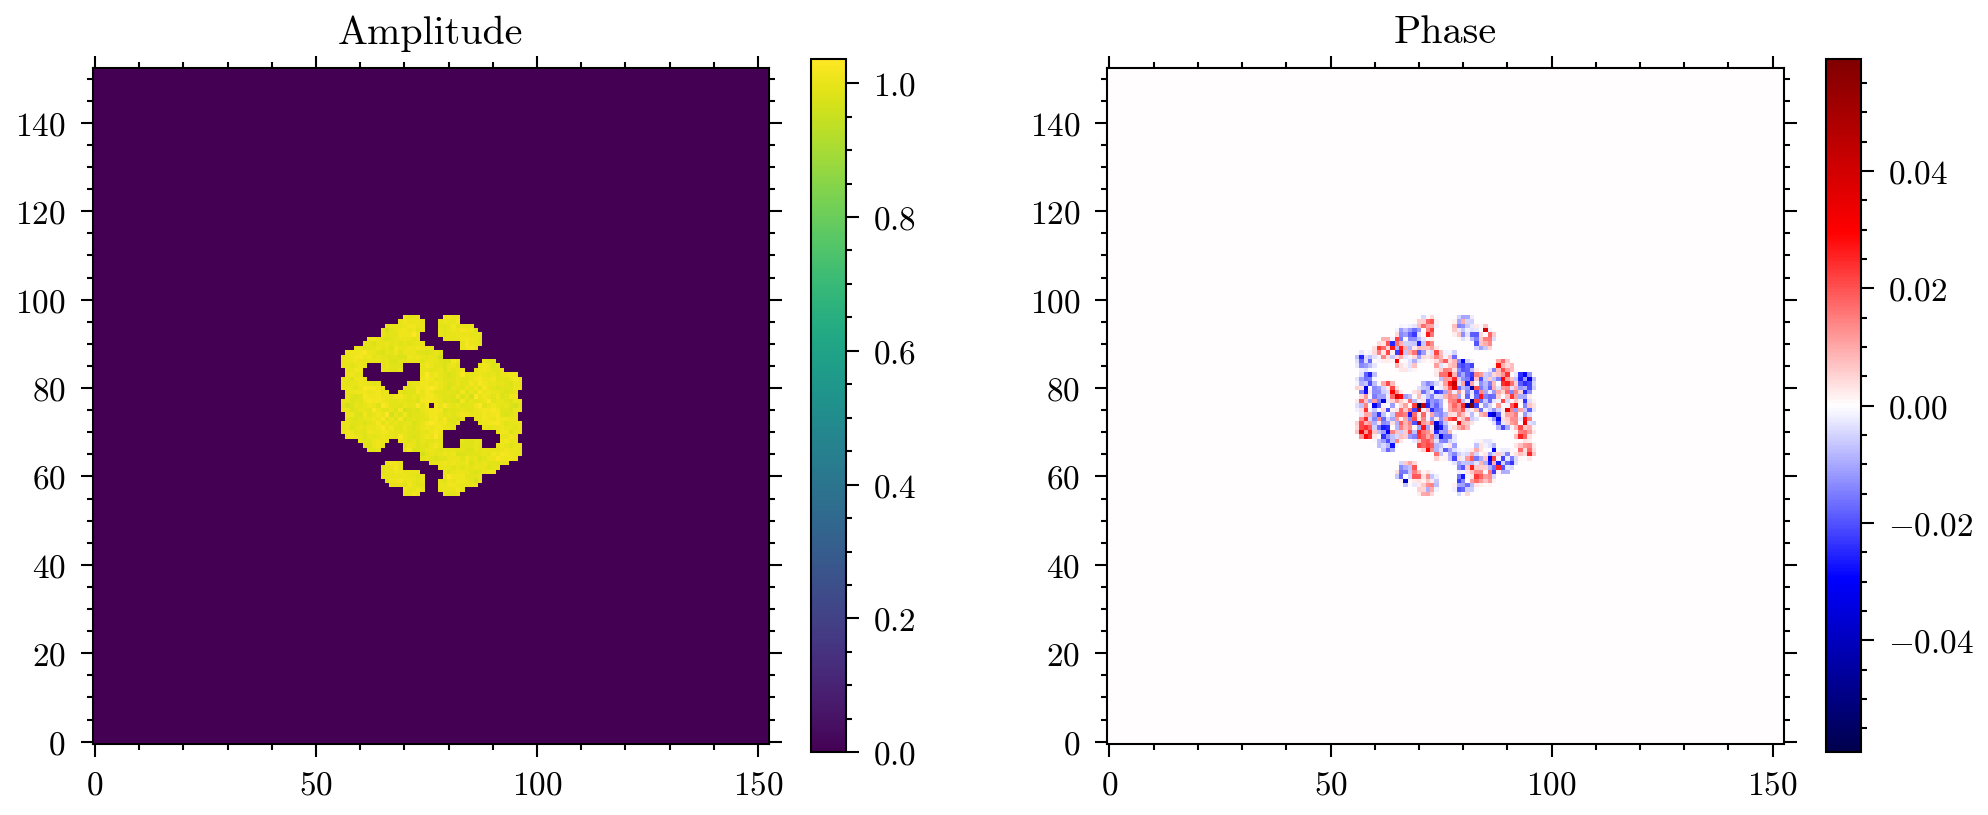

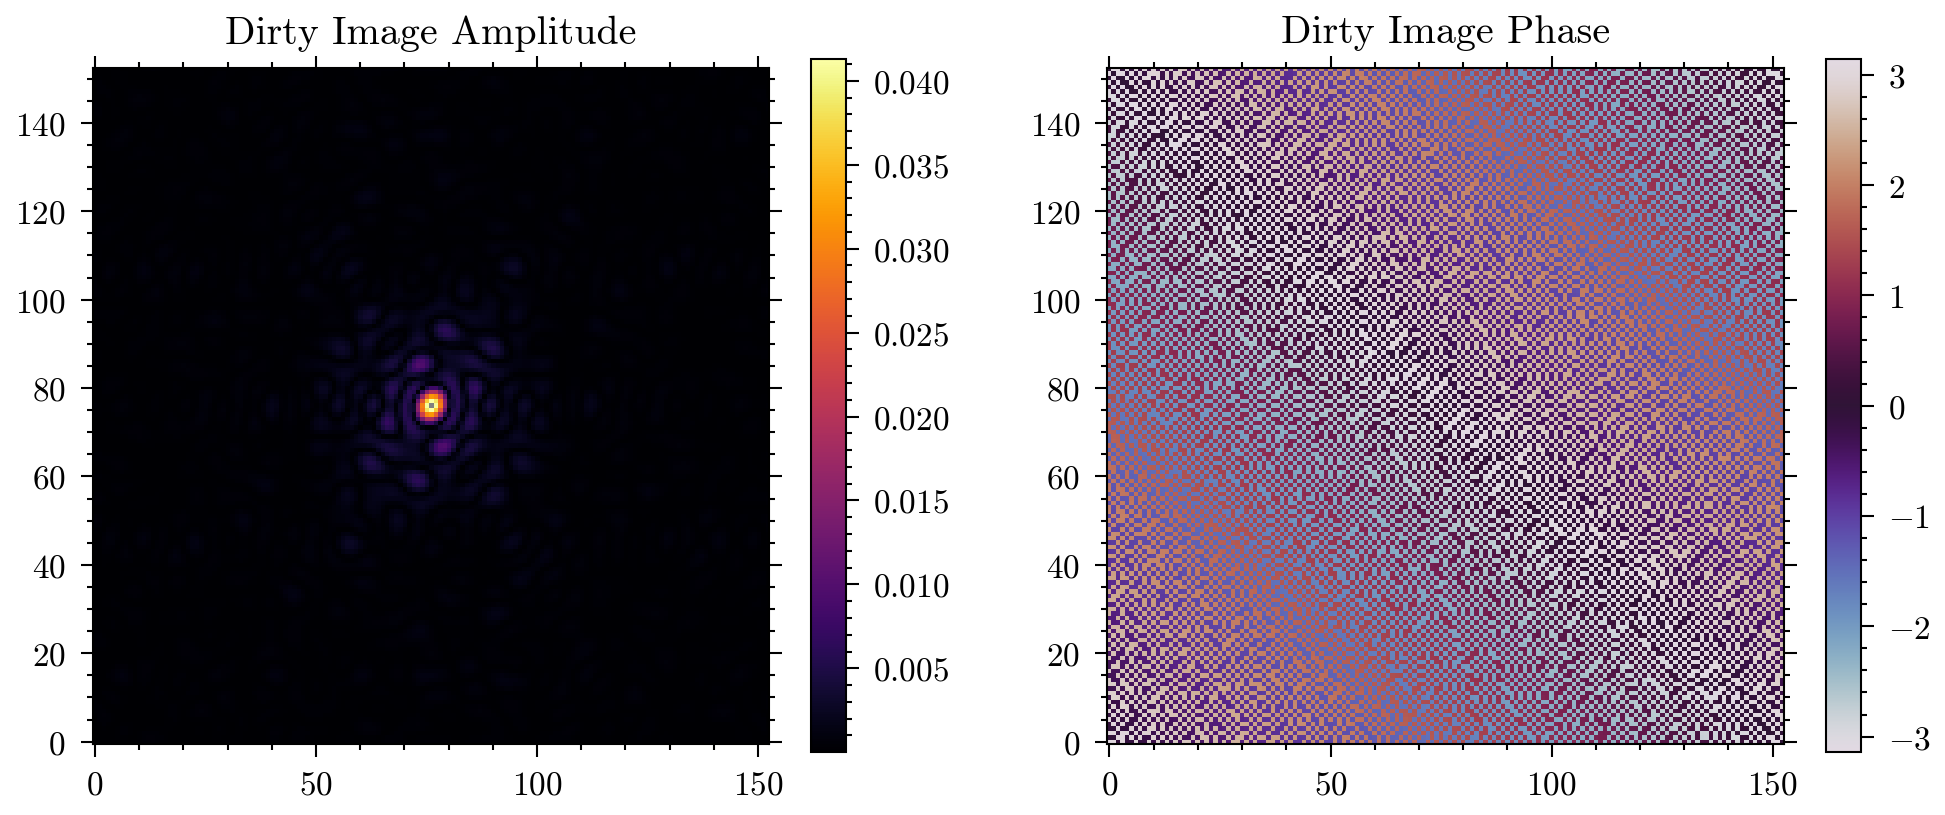

In [8]:
pad = 1
pix_cvis_pad = np.pad(
    masked_pix_cvis, uv_npix * pad, mode="constant", constant_values=0 + 0j
)

dirty_im = np.fft.fftshift(np.fft.ifft2(pix_cvis_pad))


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(pix_cvis_pad.real, cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(pix_cvis_pad.imag, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(
    np.abs(dirty_im).at[dirty_im.shape[0] // 2, dirty_im.shape[0] // 2].set(np.nan),
    cmap=inferno,
)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_im), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

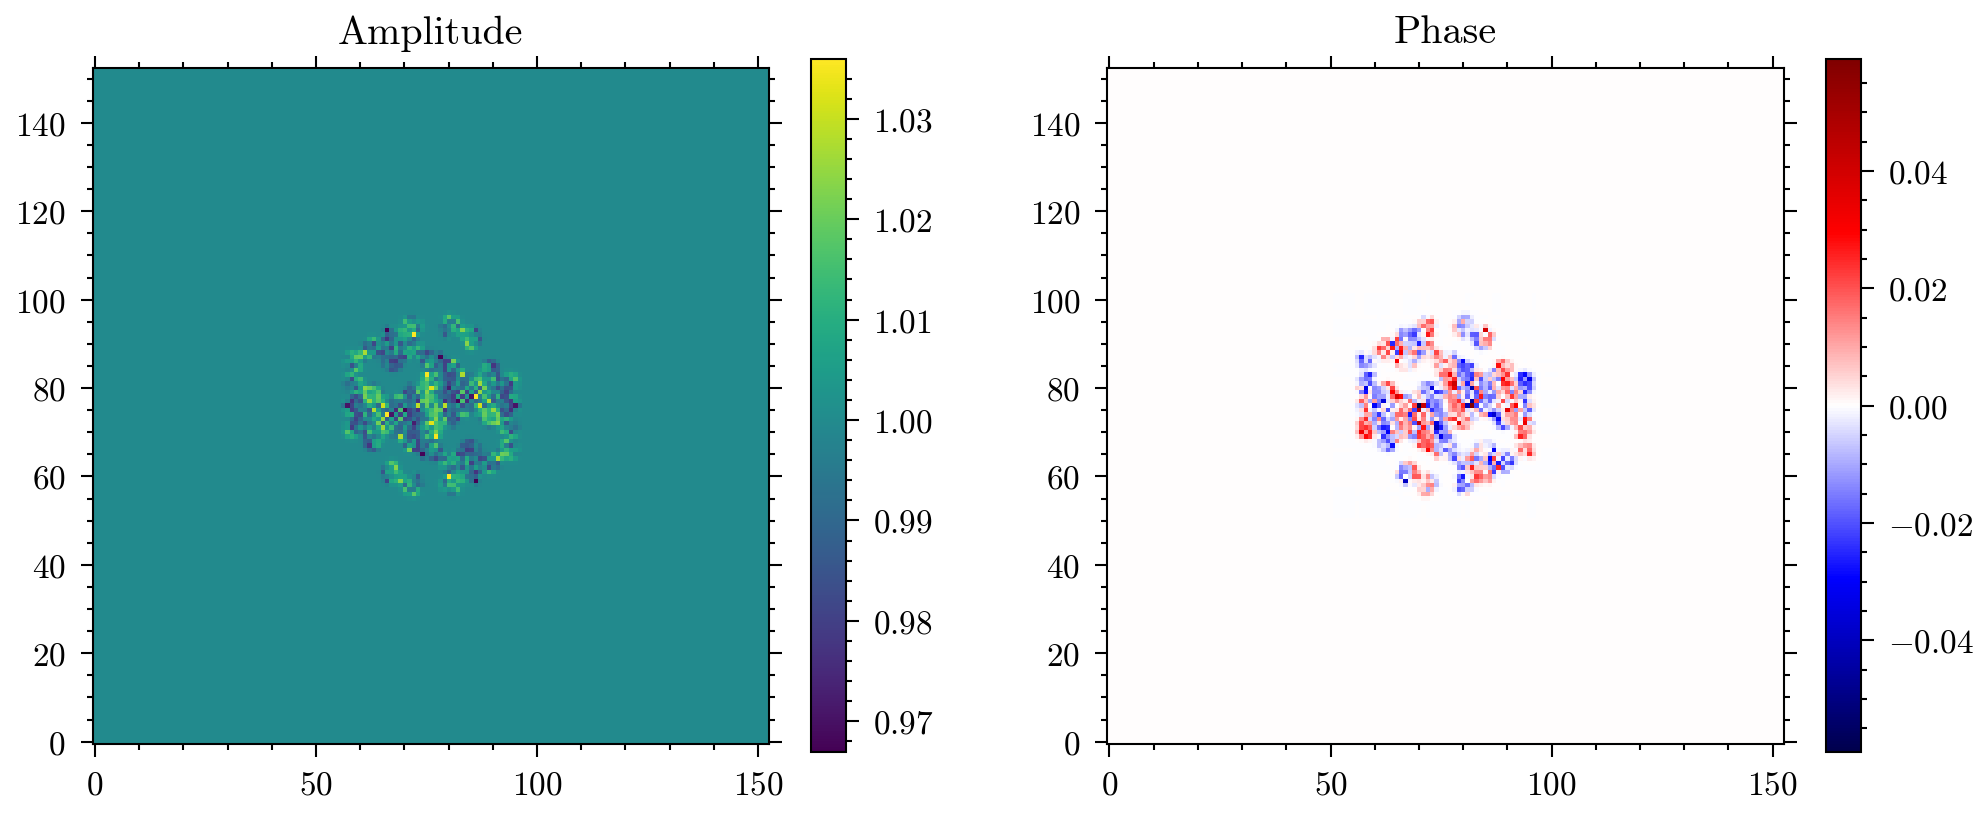

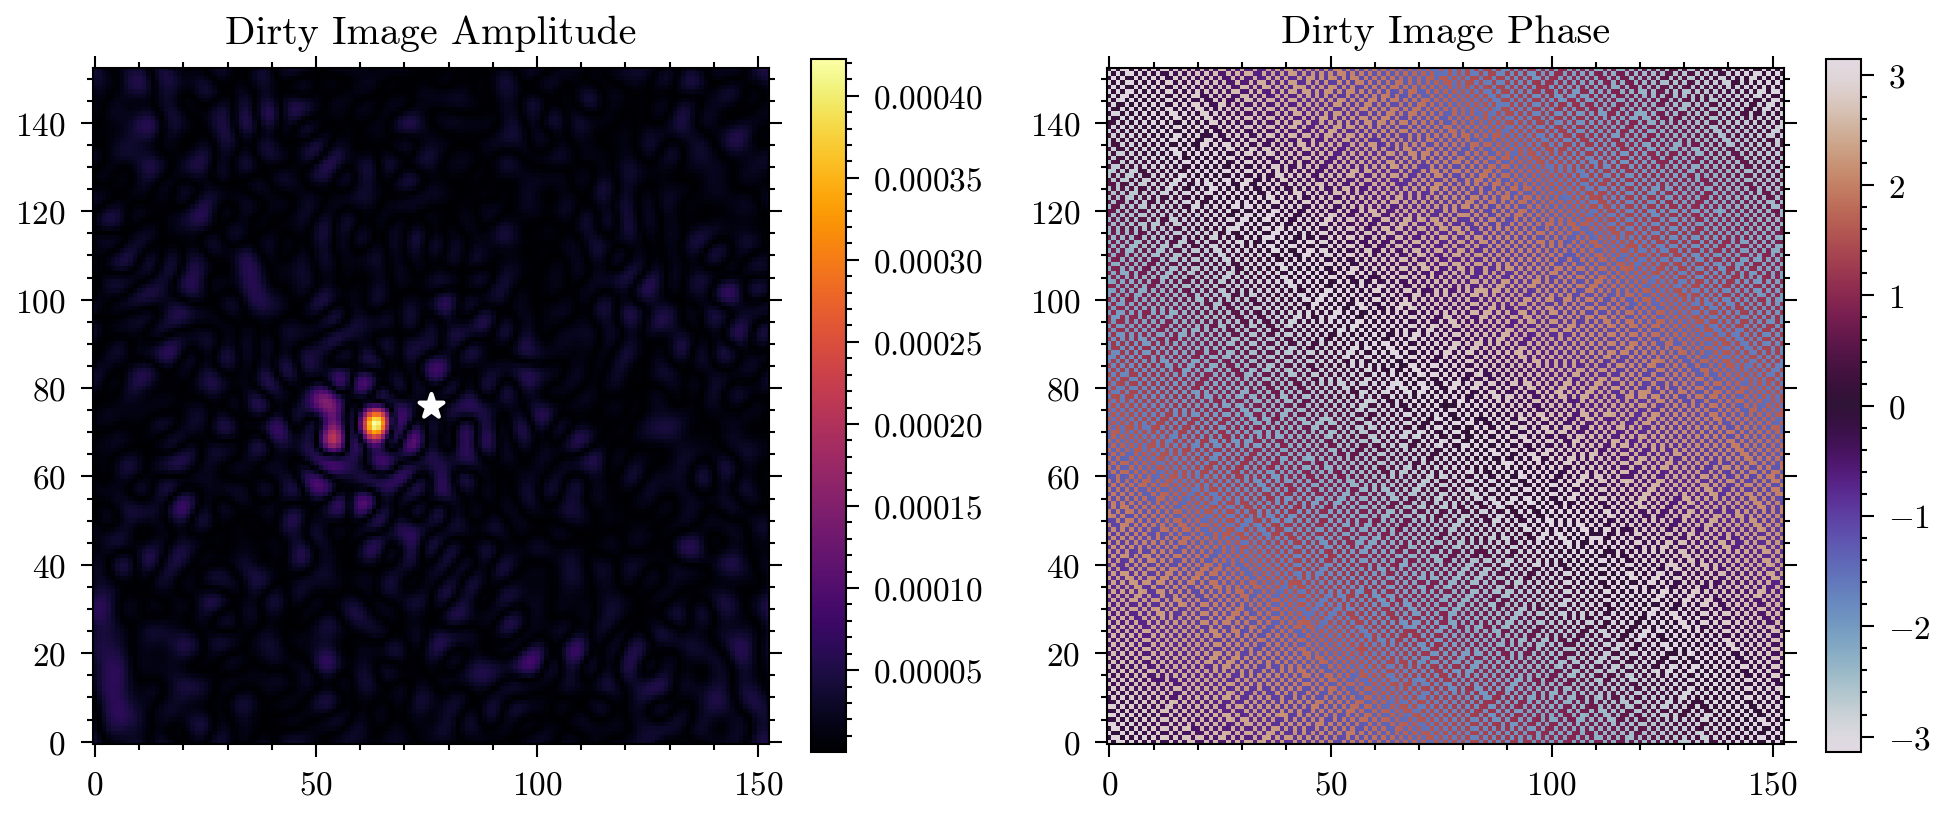

In [9]:
pad = 1
pix_cvis_pad = np.pad(pix_cvis, uv_npix * pad, mode="constant", constant_values=1 + 0j)

dirty_im = np.fft.fftshift(np.fft.ifft2(pix_cvis_pad))


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Amplitude")
plt.imshow(pix_cvis_pad.real, cmap=viridis)
plt.colorbar()
plt.subplot(122)
plt.title("Phase")
plt.imshow(pix_cvis_pad.imag, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()


plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.scatter(
    [dirty_im.shape[0] // 2], [dirty_im.shape[0] // 2], marker="*", color="white"
)
plt.imshow(
    np.abs(dirty_im).at[dirty_im.shape[0] // 2, dirty_im.shape[0] // 2].set(np.nan),
    cmap=inferno,
)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_im), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [10]:
cvis1 = pix_cvis.flatten()[: oi.u.size]
cvis2 = pix_cvis.flatten()[oi.u.size + 1 :]
otf1 = otf_support.flatten()[: oi.u.size]
otf2 = otf_support.flatten()[oi.u.size + 1 :]
us_in1 = oi.u[otf1]
us_in2 = -oi.u[::-1][otf2]
vs_in1 = oi.v[otf1]
vs_in2 = -oi.v[::-1][otf2]
cvis_in1 = cvis1[otf1]
cvis_in2 = cvis2[otf2]

print(pix_cvis.shape)
print(oi.u.shape, oi.v.shape)
print(cvis1.shape, cvis2.shape)
print(otf1.shape, otf2.shape)
print(us_in1.shape, us_in2.shape)
print(vs_in1.shape, vs_in2.shape)
print(cvis_in1.shape, cvis_in2.shape)

(51, 51)
(1300,) (1300,)
(1300,) (1300,)
(1300,) (1300,)
(526,) (526,)
(526,) (526,)
(526,) (526,)


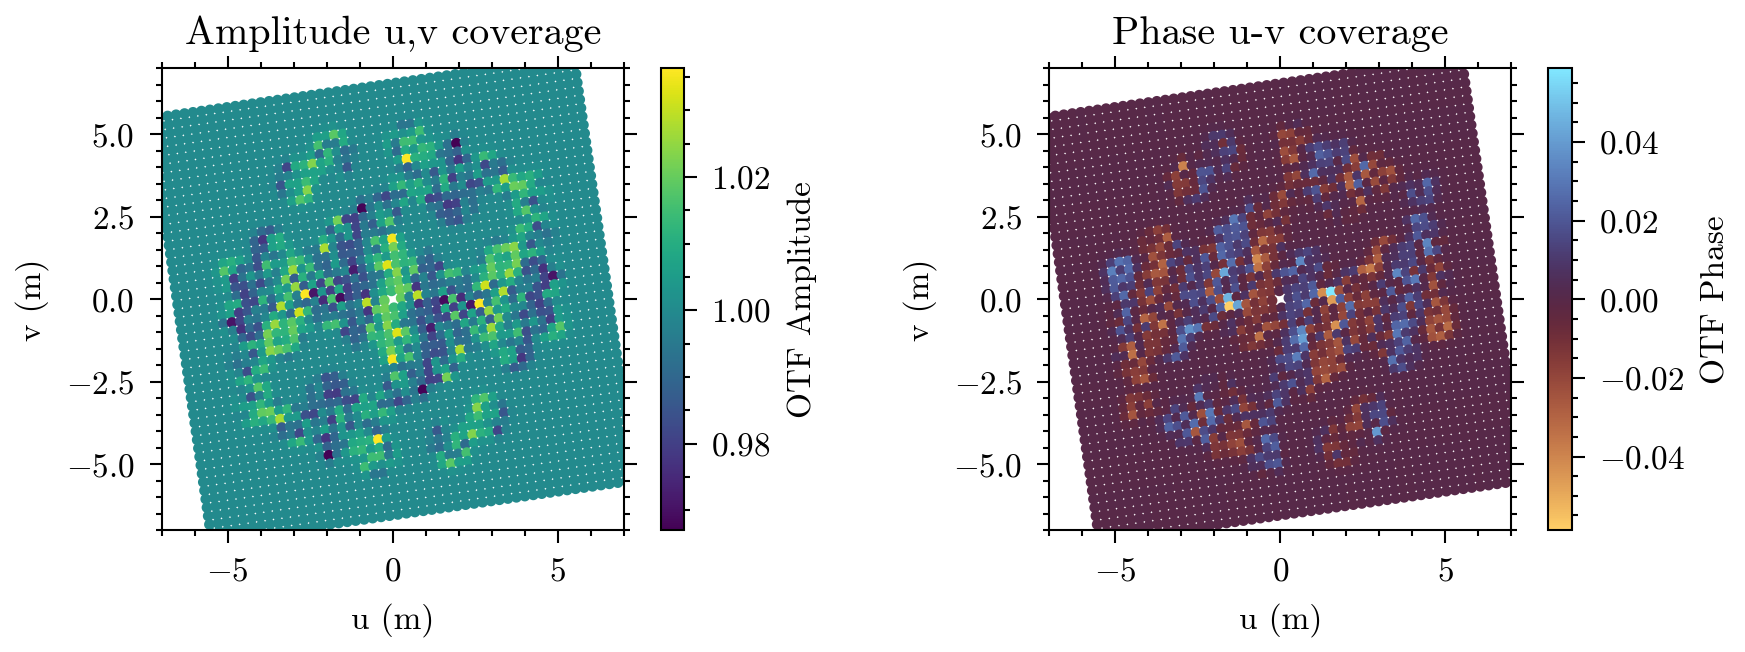

In [11]:
plt.figure(figsize=(7, 2))
plt.subplot(121)
plt.scatter(oi.u, oi.v, marker="o", s=2.5, c=np.abs(cvis1), cmap="viridis")
plt.scatter(
    -oi.u[::-1], -oi.v[::-1], marker="o", s=2.5, c=np.abs(cvis2), cmap="viridis"
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Amplitude u,v coverage")
plt.colorbar(label="OTF Amplitude")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.subplot(122)
plt.scatter(
    oi.u,
    oi.v,
    marker="o",
    s=2.5,
    c=np.angle(cvis1),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.scatter(
    -oi.u[::-1],
    -oi.v[::-1],
    marker="o",
    s=2.5,
    c=np.angle(cvis2),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Phase u-v coverage")
plt.colorbar(label="OTF Phase")
plt.xlim(-7, 7)
plt.ylim(-7, 7)

plt.show()

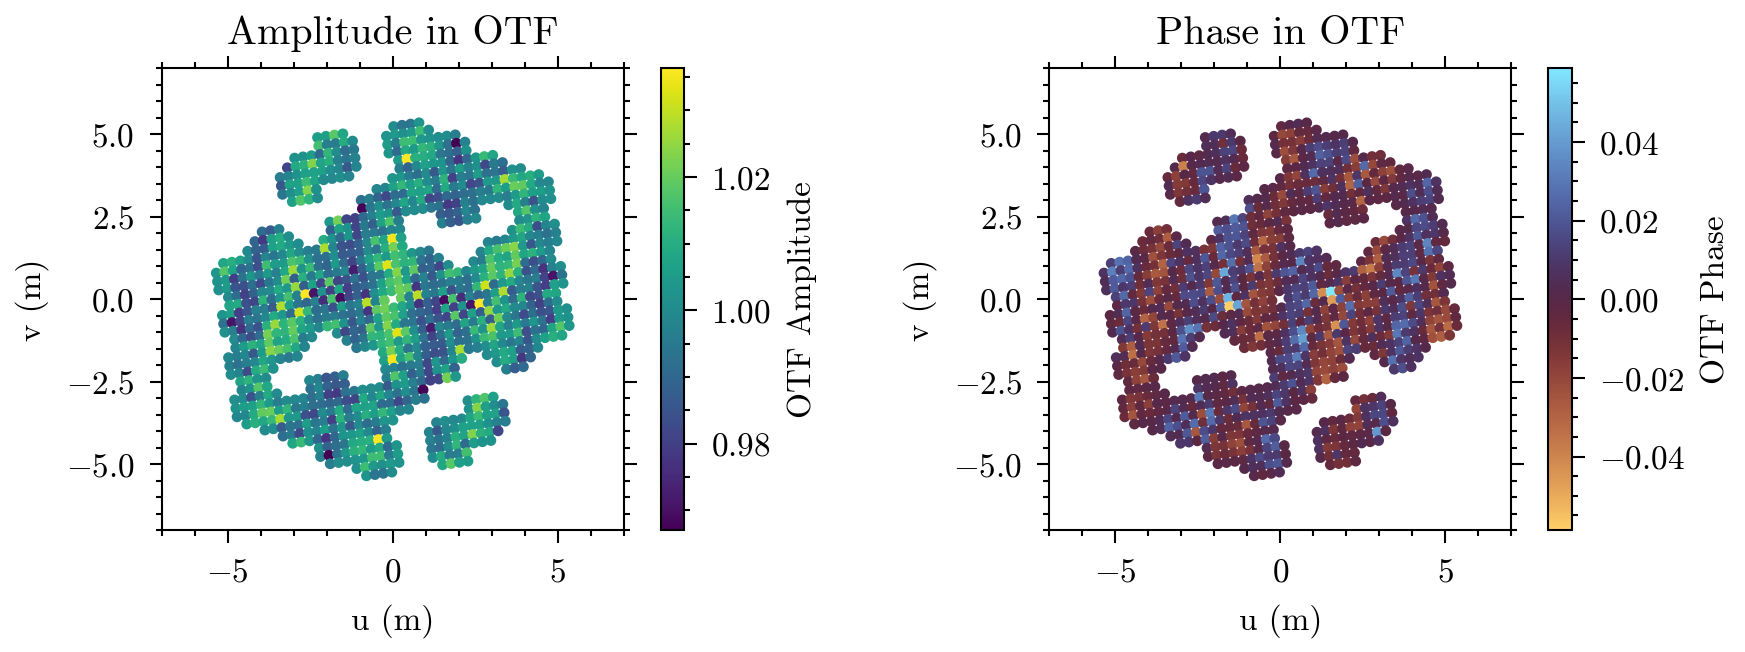

In [12]:
plt.figure(figsize=(7, 2))
plt.subplot(121)
plt.scatter(us_in1, vs_in1, marker="o", s=2.5, c=np.abs(cvis_in1), cmap="viridis")
plt.scatter(us_in2, vs_in2, marker="o", s=2.5, c=np.abs(cvis_in2), cmap="viridis")
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Amplitude in OTF")
plt.colorbar(label="OTF Amplitude")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.subplot(122)
plt.scatter(
    us_in1,
    vs_in1,
    marker="o",
    s=2.5,
    c=np.angle(cvis_in1),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.scatter(
    us_in2,
    vs_in2,
    marker="o",
    s=2.5,
    c=np.angle(cvis_in2),
    cmap="managua",
    norm=mpl.colors.CenteredNorm(),
)
plt.axis("square")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title("Phase in OTF")
plt.colorbar(label="OTF Phase")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.show()

In [24]:
from jax_finufft import nufft1

uv_coords = np.vstack([us_in1, vs_in1])
print(uv_coords.shape)

vis = cvis_in1
print(vis.shape)

im_npix = 101

dirty_image = nufft1((im_npix, im_npix), vis, *uv_coords)

(2, 526)
(526,)


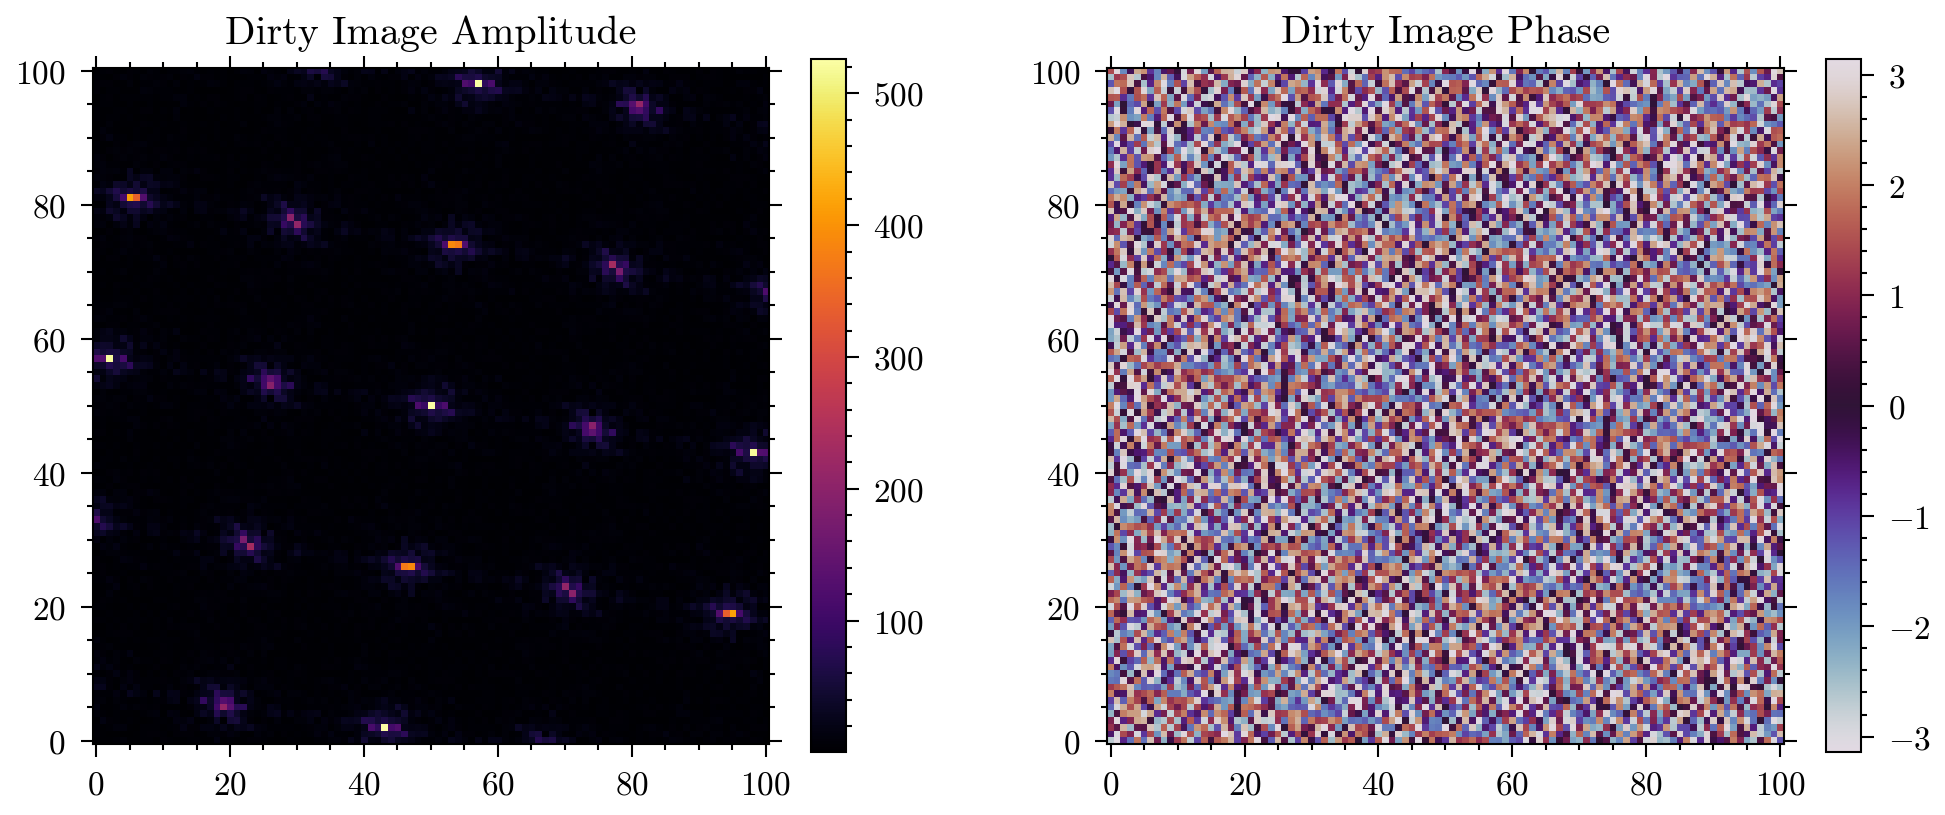

In [25]:
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.title("Dirty Image Amplitude")
plt.imshow(np.abs(dirty_image), cmap=inferno)
plt.colorbar()
plt.subplot(122)
plt.title("Dirty Image Phase")
plt.imshow(np.angle(dirty_image), cmap="twilight", norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()